In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import date, timedelta
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colors
#warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
datad = pd.read_csv('/Users/yuanqihong/Desktop/URANIA_partitioning/camels_600.txt',delimiter=';')


##### Land cover info

In [3]:
## Vegetation cover
dir_vegetation = ('/Users/yuanqihong/Desktop/URANIA_partitioning/camels_attributes_v2.0/camels_attributes_v2.0/')
camels_vege = pd.read_csv(dir_vegetation + "camels_vege.txt",delimiter=';')
camels_climx = pd.read_csv(dir_vegetation + "camels_clim.txt",delimiter=';')              
camels_topo = pd.read_csv(dir_vegetation + "camels_topo.txt",delimiter=';')
camels_topo = camels_topo.merge(camels_climx,left_on='gauge_id',right_on='gauge_id')
camels_vegex = camels_vege.merge(datad, 
                                 on='gauge_id').merge(camels_topo, on='gauge_id')


In [4]:
# xarray
import geopandas as gpd
import xarray 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
CRS = "EPSG:5070"

In [5]:
### gdf                                                          
camels_vege_finaly_gdf = gpd.GeoDataFrame(camels_vegex, geometry=gpd.points_from_xy(
                             camels_vegex.gauge_lon, camels_vegex.gauge_lat))
camels_vege_finaly_gdf.crs = "EPSG:4326"
camels_vege_finaly_gdf = camels_vege_finaly_gdf.to_crs(CRS)
camels_vege_finaly_gdf['lond'] = np.array(camels_vege_finaly_gdf.geometry.x)
camels_vege_finaly_gdf['latd'] = np.array(camels_vege_finaly_gdf.geometry.y)

#xarray
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdf.to_xarray()
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdfXarray.set_coords(['lond', 'latd'])

In [6]:
conus_states = gpd.read_file('/Users/yuanqihong/Desktop/new_pdm/tl_2017_us_state/tl_2017_us_state.shp')

four types map

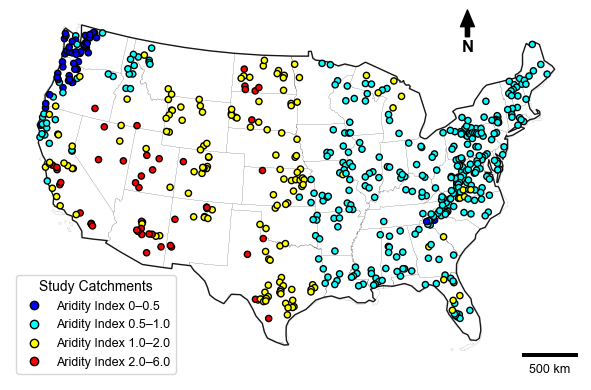

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

# =========================
# Settings
# =========================
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": "none", "edgecolor": "k", "alpha": 0.9, "linewidth": 0.07}
BASE_PLOT1 = {"facecolor": "none", "edgecolor": "k", "alpha": 0.9}

plt.rcParams["font.family"] = "Arial"

CRS = "EPSG:5070"

# =========================
# Load map
# =========================
world = gpd.read_file(
    "/Users/yuanqihong/Desktop/new_pdm/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
)
conus = world[world["ADMIN"] == "United States of America"]

# =========================
# Aridity classes
# =========================
nlevels = [0, 0.5, 1.0, 2.0, 6.0]
colors_list = ["blue", "cyan", "yellow", "red"]

cmap = colors.ListedColormap(colors_list)
norm = colors.BoundaryNorm(nlevels, cmap.N)

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(8, 4))

conus_states.to_crs(CRS).plot(ax=ax, **BASE_PLOT)
conus.to_crs(CRS).plot(ax=ax, **BASE_PLOT1)

# =========================
# Scatter
# =========================
xr.plot.scatter(
    camels_vege_finaly_gdfXarray,
    x="lond",
    y="latd",
    hue="aridity_x",
    s=20,
    edgecolors="k",
    linewidth=0.075,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    ax=ax,
    zorder=3
)

# =========================
# Legend: lower left
# =========================
legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="blue", markeredgecolor="k",
           markersize=6, label="Aridity Index 0–0.5"),

    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="cyan", markeredgecolor="k",
           markersize=6, label="Aridity Index 0.5–1.0"),

    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="yellow", markeredgecolor="k",
           markersize=6, label="Aridity Index 1.0–2.0"),

    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="red", markeredgecolor="k",
           markersize=6, label="Aridity Index 2.0–6.0"),
]

ax.legend(
    handles=legend_handles,
    title="Study Catchments",
    loc="lower left",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# =========================
# Extent
# =========================
ax.set_ylim([0, 3.3 * 1e6])
ax.set_xlim([-2.6 * 1e6, 2.5 * 1e6])

# =========================
# Scale bar: lower right, fixed 500 km
# =========================
scalebar = ScaleBar(
    dx=1,                  # EPSG:5070 unit = meter
    units="m",
    dimension="si-length",
    location="lower right",

    fixed_value=500,
    fixed_units="km",

    box_alpha=0,
    color="k",
    font_properties={"size": 9}
)

ax.add_artist(scalebar)

# =========================
# North arrow: upper right
# =========================
xlim = ax.get_xlim()
ylim = ax.get_ylim()

x_arrow = xlim[1] - 0.2 * (xlim[1] - xlim[0])
y_arrow_base = ylim[1] - 0.1 * (ylim[1] - ylim[0])


arrow_len = 0.10 * (ylim[1] - ylim[0])

ax.annotate(
    "N",
    xy=(x_arrow, y_arrow_base + arrow_len),
    xytext=(x_arrow, y_arrow_base),
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(
        facecolor="k",
        edgecolor="k",
        width=3,        
        headwidth=10,   
        headlength=12  
    ),
    zorder=6
)

# =========================
# Format
# =========================
ax.axis(False)
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)

plt.tight_layout()

plt.savefig(
    "/Users/yuanqihong/Desktop/URANIA_partitioning/AI_map.png",
    **SAVE_KWDS
)

plt.show()